In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

start_time = time.time()

# ==========================================
# PHASE 1: EFFICIENT DATA LOADING & PREP
# ==========================================
print("1. Loading Data...")
# engine='pyarrow' makes loading CSVs much faster
train_df = pd.read_csv('train.csv', engine='pyarrow')
test_df = pd.read_csv('test.csv', engine='pyarrow')

# Downcast 64-bit floats to 32-bit to save memory
train_df['demand'] = train_df['demand'].astype('float32')
if 'Temperature' in train_df.columns:
    train_df['Temperature'] = train_df['Temperature'].astype('float32')
    test_df['Temperature'] = test_df['Temperature'].astype('float32')

# Handle Categorical Columns for both EDA and CatBoost
categorical_features = ['geohash', 'timestamp', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
for col in categorical_features:
    train_df[col] = train_df[col].fillna('Missing').astype(str)
    test_df[col] = test_df[col].fillna('Missing').astype(str)

# ==========================================
# PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n2. Running Fast EDA...")
print(f"Unique Geohashes: {train_df['geohash'].nunique()}")
print(f"Unique Timestamps: {train_df['timestamp'].nunique()}")

print("\n--- Average Demand by Categories ---")
print("By Weather:\n", train_df.groupby('Weather')['demand'].mean())
print("\nBy RoadType:\n", train_df.groupby('RoadType')['demand'].mean())

# Multi-column aggregation
print("\n--- RoadType & LargeVehicles Demand ---")
print(train_df.groupby(['RoadType', 'LargeVehicles'])['demand'].mean())

# ==========================================
# PHASE 3: MODEL TRAINING & EFFICIENCY CHECK
# ==========================================
print("\n3. Preparing Model Features...")
X = train_df.drop(columns=['Index', 'demand'], errors='ignore')
y = train_df['demand']
X_test = test_df.drop(columns=['Index'], errors='ignore')

# Split 20% of data to check efficiency (validation set)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n4. Training CatBoost Model...")
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    eval_metric='RMSE',
    verbose=100, # Print progress every 100 steps
    random_seed=42
)

# Train the model with early stopping
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

print("\n5. Checking Model Efficiency...")
val_predictions = model.predict(X_val)
r2 = r2_score(y_val, val_predictions)
rmse = np.sqrt(mean_squared_error(y_val, val_predictions))

print(f"-> Model Efficiency (R-Squared): {r2 * 100:.2f}%")
print(f"-> RMSE (Error margin): {rmse:.4f}")

# ==========================================
# PHASE 4: PREDICT ON TEST & SAVE
# ==========================================
print("\n6. Predicting on test.csv...")
test_predictions = model.predict(X_test)

submission = pd.DataFrame({
    'Index': test_df['Index'], 
    'demand': test_predictions
})

submission.to_csv('catboost_submission.csv', index=False)
print(f"\nDone! Entire pipeline finished and saved to 'catboost_submission.csv' in {time.time() - start_time:.2f} seconds.")

# ==========================================
# PHASE 5: VISUALIZATIONS (Optional)
# ==========================================

plt.figure(figsize=(10, 5))
train_df['demand'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()
 train_df['demand'].hist(bins=50, color='skyblue', edgecolor='black')
 plt.title('Distribution of Demand')
 plt.xlabel('Demand')
 plt.ylabel('Frequency')
 plt.show()

--- Unique Identifiers ---
Unique Geohashes: 1249
Unique Timestamps: 96

--- Demand Averages ---
By Weather:
 Weather
Foggy    0.093372
Rainy    0.094471
Snowy    0.092581
Sunny    0.094247
Name: demand, dtype: float32 

By RoadType:
 RoadType
Highway        0.610756
Residential    0.057209
Street         0.273164
Name: demand, dtype: float32 

By Lanes:
 NumberofLanes
1    0.088104
2    0.077488
3    0.077859
4    0.602882
5    0.607556
Name: demand, dtype: float32 

By Large Vehicles:
 LargeVehicles
Allowed        0.131923
Not Allowed    0.073986
Name: demand, dtype: float32 

By Landmarks:
 Landmarks
No     0.096295
Yes    0.092801
Name: demand, dtype: float32 

By Day:
 day
48    0.092659
49    0.105262
Name: demand, dtype: float32 

--- Timestamp Statistics ---
Top 10 Highest Demand:
 timestamp
13:30    0.119193
11:15    0.119174
14:0     0.117821
12:0     0.117790
11:30    0.117561
11:45    0.117129
13:45    0.117046
13:15    0.116641
11:0     0.115395
12:15    0.114676
Name: dem

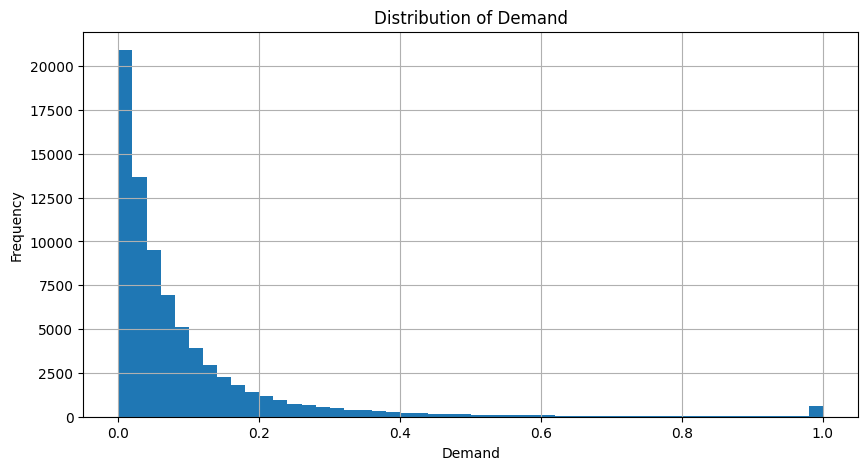

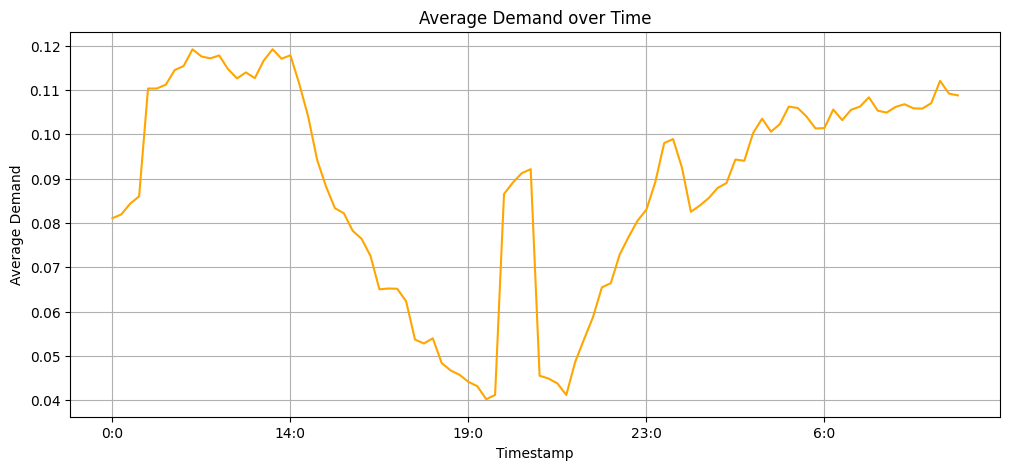

In [8]:
import matplotlib.pyplot as plt

# 1. Histogram of the Demand distribution
plt.figure(figsize=(10, 5))
df['demand'].hist(bins=50)
plt.title('Distribution of Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show() # <-- This is the command that actually pops the graph open on your screen

# 2. If you want to see the Timestamp vs Demand trend:
plt.figure(figsize=(12, 5))
# We sort by index to make sure the time flows chronologically
timestamp_mean.sort_index().plot(kind='line', color='orange')
plt.title('Average Demand over Time')
plt.xlabel('Timestamp')
plt.ylabel('Average Demand')
plt.grid(True)
plt.show()